# SEIRS-SEI Malaria Model

ODE approximation of SEIRS-SEI DDE model with yearly population from IBGE data, based on the results of 
### data_files/notebooks/Biting_Rate_Estimation.ipynb ###

From this file, we have $T'=16^\circ C, \ D_1=24.8$ and $m$, which we assume to be equal to $M_0$ in this case, is $9.9N_0$

In [2]:
from seirs_sei_ode_shared import *
%matplotlib inline

Data loaded and filtered successfully!
Climate data: 2556 days
Cases data: 2556 days
Pop data: 2556 days
Deforestation data: 3288 days
Forest fires data: 3288 days

IBGE rural population by year (2017-2023):
2017: 8368.62
2018: 8260.48
2019: 8152.73
2020: 8045.43
2021: 7938.61
2022: 7832.33
2023: 7942.25
The initial ratio of exposed to infected mosquitos was estimated to be ~3
Initial human compartments in 2017: N=8369, S_H=5752, E_H=418, I_H=944, R_H=1255
Initial mosquito compartments in 2017: M=82853.1, S_M=79537.1, E_M=2487, I_M=829


In [3]:
#### Yearly Simulation (2017-2023)
years = list(range(2017, 2024))
all_results = []
current_state = initial_state_2017.copy()

for year in years:
    print(f"\nSimulating {year}...")
    N = round(pop_by_year[year])
    start = f"{year}-01-01"
    end = f"{year}-12-31"
    year_climate = climate_data[(climate_data['date'] >= start) & (climate_data['date'] <= end)].reset_index(drop=True)
    num_days = len(year_climate)
    print(f"Year {year}: N={N}, Days={num_days}")
    
    def ode_func(t, z):
        return seirs_sei_ode(t, z, N, year_climate,
                            T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
                            c1, c2, D1, b1, b2, A, B, C, DD, 
                            Tmin, optimal_temp_plasm, critical_max_temp_plasm,
                            optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
                            gamma, R_L, M_prime, tau_H, omega)
    
    sol = solve_ivp(ode_func, [0, num_days], current_state, 
                    t_eval=np.linspace(0, num_days, num_days*10), method='LSODA') #'DOP853')
    
    all_results.append({'year': year, 'N': N, 'sol': sol, 'climate': year_climate})
    current_state = sol.y[:, -1].copy()
    print(f"Finished {year}. Final I_H: {round(current_state[2])}, Final I_M: {round(current_state[6])}")

print("\nAll years simulated successfully!")


Simulating 2017...
Year 2017: N=8369, Days=365
Finished 2017. Final I_H: 138, Final I_M: 22

Simulating 2018...
Year 2018: N=8260, Days=365
Finished 2018. Final I_H: 14, Final I_M: 1

Simulating 2019...
Year 2019: N=8153, Days=365
Finished 2019. Final I_H: 2, Final I_M: 0

Simulating 2020...
Year 2020: N=8045, Days=366
Finished 2020. Final I_H: 0, Final I_M: 0

Simulating 2021...
Year 2021: N=7939, Days=365
Finished 2021. Final I_H: 0, Final I_M: 0

Simulating 2022...
Year 2022: N=7832, Days=365
Finished 2022. Final I_H: 0, Final I_M: 0

Simulating 2023...
Year 2023: N=7942, Days=365
Finished 2023. Final I_H: 0, Final I_M: 0

All years simulated successfully!


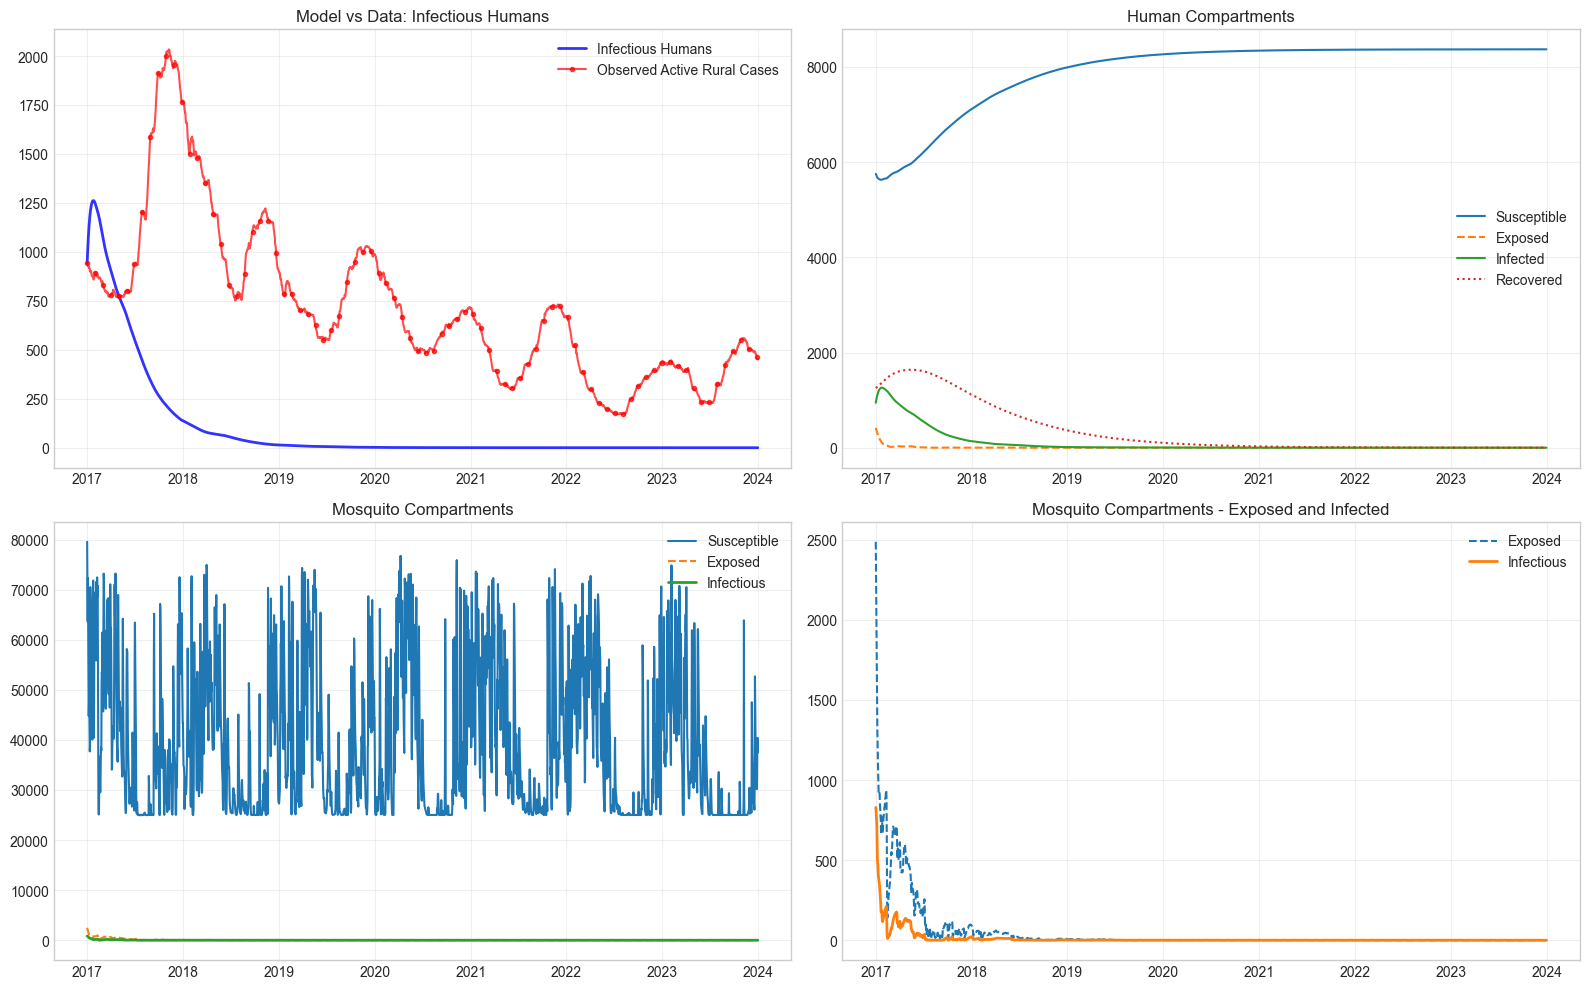

In [4]:
#### Combine and Plot Results
combined_df = pd.DataFrame()
for res in all_results:
    year = res['year']
    sol = res['sol']
    climate = res['climate']
    
    # Interpolate to daily resolution
    t_interp = np.linspace(0, sol.t[-1], len(climate))
    interp = [interp1d(sol.t, sol.y[i])(t_interp) for i in range(7)]
    
    df = pd.DataFrame({
        'date': pd.to_datetime(climate['date']).values,
        'S_H': interp[0], 'E_H': interp[1], 'I_H': interp[2], 'R_H': interp[3],
        'S_M': interp[4], 'E_M': interp[5], 'I_M': interp[6], 'N': res['N']
    })
    combined_df = pd.concat([combined_df, df]).reset_index(drop=True)

# Ensure date columns are datetime
combined_df['date'] = pd.to_datetime(combined_df['date'])
rural_cases_df['date'] = pd.to_datetime(rural_cases_df['date'])

# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0,0].plot(combined_df['date'], combined_df['I_H'], 'b-', linewidth=2, label='Infectious Humans', alpha=0.8)
axes[0,0].plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.5, 
        label='Observed Active Rural Cases', alpha=0.7, marker='o', 
        markersize=3, markevery=30)  # Show markers every ~1 month for readability
axes[0,0].set_title('Model vs Data: Infectious Humans')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(combined_df['date'], combined_df['S_H'], label='Susceptible')
axes[0,1].plot(combined_df['date'], combined_df['E_H'], label='Exposed', linestyle='--')
axes[0,1].plot(combined_df['date'], combined_df['I_H'], label='Infected', linestyle='-')
axes[0,1].plot(combined_df['date'], combined_df['R_H'], label='Recovered', linestyle=':')
axes[0,1].set_title('Human Compartments'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(combined_df['date'], combined_df['S_M'], label='Susceptible', linewidth=1.5)
axes[1,0].plot(combined_df['date'], combined_df['E_M'], label='Exposed', linewidth=1.5, linestyle='--')
axes[1,0].plot(combined_df['date'], combined_df['I_M'], label='Infectious', linewidth=2)
axes[1,0].set_title('Mosquito Compartments'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(combined_df['date'], combined_df['E_M'], label='Exposed', linewidth=1.5, linestyle='--')
axes[1,1].plot(combined_df['date'], combined_df['I_M'], label='Infectious', linewidth=2)
axes[1,1].set_title('Mosquito Compartments - Exposed and Infected'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


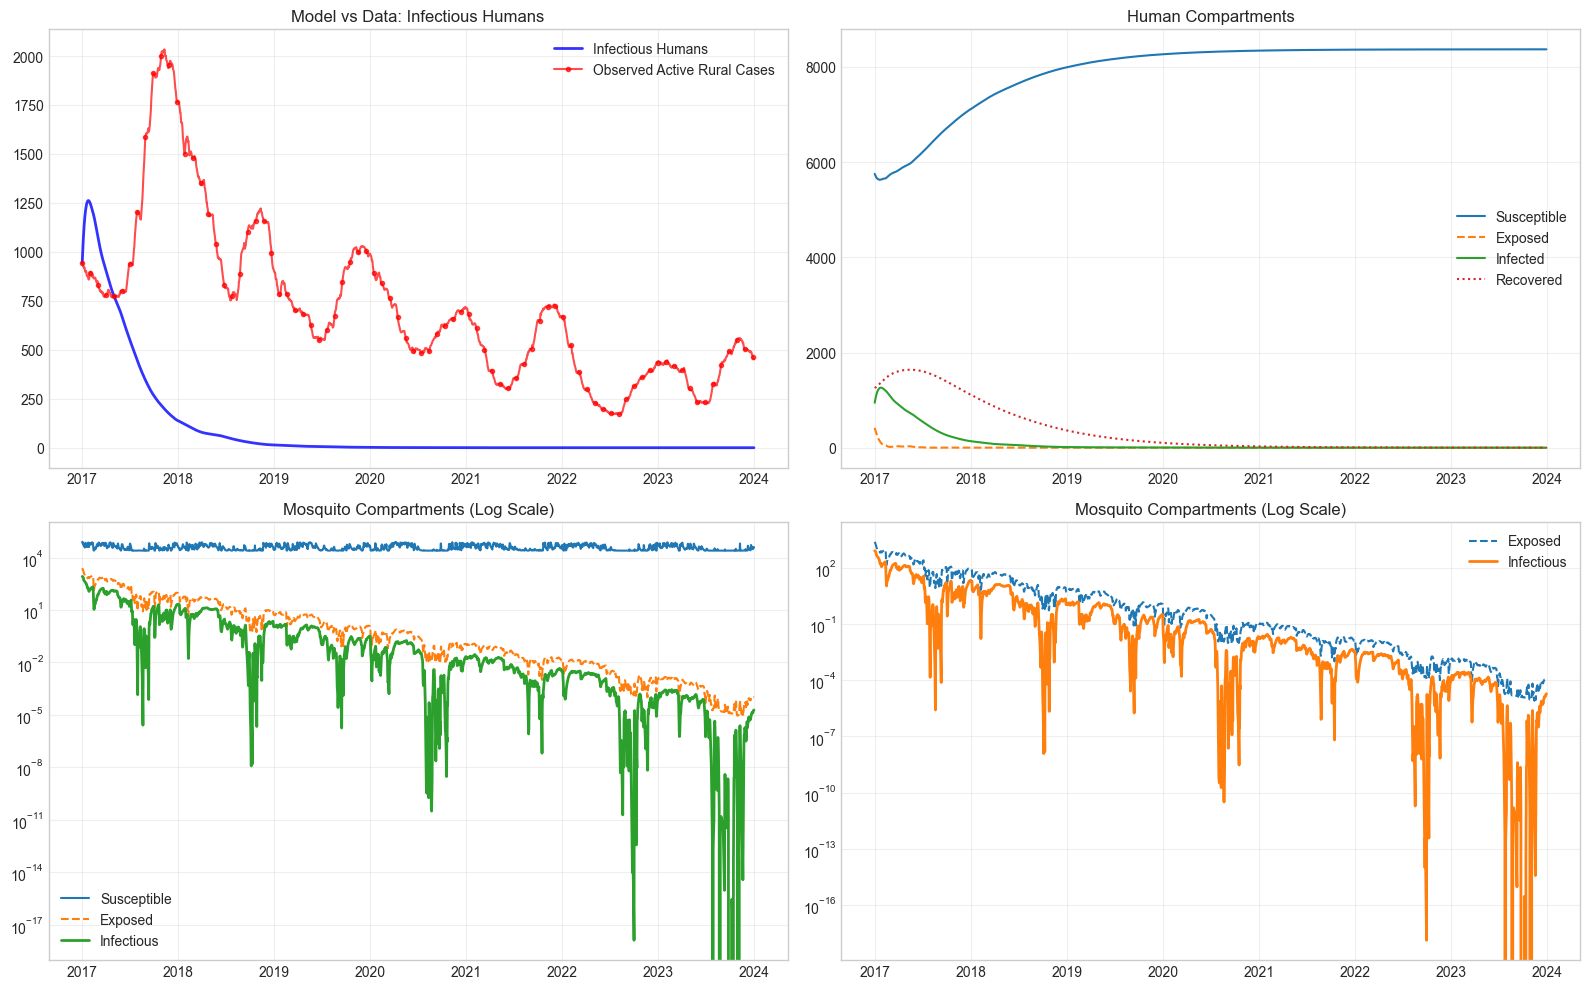

In [5]:
# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Infectious humans vs observed data
axes[0,0].plot(
    combined_df['date'],
    combined_df['I_H'],
    'b-',
    linewidth=2,
    label='Infectious Humans',
    alpha=0.8
)

axes[0,0].plot(
    rural_cases_df['date'],
    rural_cases_df['active_total'],
    'r-',
    linewidth=1.5,
    label='Observed Active Rural Cases',
    alpha=0.7,
    marker='o',
    markersize=3,
    markevery=30
)

axes[0,0].set_title('Model vs Data: Infectious Humans')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)


# Human compartments
axes[0,1].plot(combined_df['date'], combined_df['S_H'], label='Susceptible')
axes[0,1].plot(combined_df['date'], combined_df['E_H'], label='Exposed', linestyle='--')
axes[0,1].plot(combined_df['date'], combined_df['I_H'], label='Infected', linestyle='-')
axes[0,1].plot(combined_df['date'], combined_df['R_H'], label='Recovered', linestyle=':')

axes[0,1].set_title('Human Compartments')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)


# Mosquito compartments (LOG SCALE)
axes[1,0].plot(
    combined_df['date'],
    combined_df['S_M'],
    label='Susceptible',
    linewidth=1.5
)

axes[1,0].plot(
    combined_df['date'],
    combined_df['E_M'],
    label='Exposed',
    linewidth=1.5,
    linestyle='--'
)

axes[1,0].plot(
    combined_df['date'],
    combined_df['I_M'],
    label='Infectious',
    linewidth=2
)

# Apply logarithmic scale
axes[1,0].set_yscale('log')
axes[1,0].set_title('Mosquito Compartments (Log Scale)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3, which='both')

axes[1,1].plot(
    combined_df['date'],
    combined_df['E_M'],
    label='Exposed',
    linewidth=1.5,
    linestyle='--'
)

axes[1,1].plot(
    combined_df['date'],
    combined_df['I_M'],
    label='Infectious',
    linewidth=2
)

# Apply logarithmic scale
axes[1,1].set_yscale('log')
axes[1,1].set_title('Mosquito Compartments (Log Scale)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

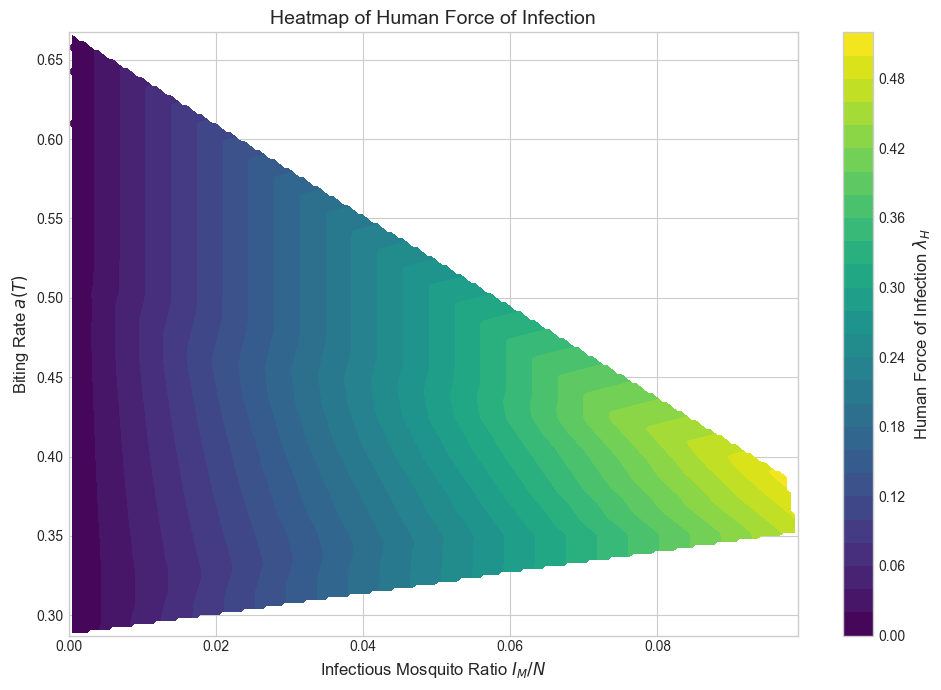

In [6]:
combined_df['Temp'] = climate_data['temp_med'].values[:len(combined_df)]

# Compute a(T) and b3(T)
combined_df['a_T'] = combined_df['Temp'].apply(a)
combined_df['b_3'] = combined_df['Temp'].apply(b3_briere_scaled_plasm)

# Infectious mosquito ratio
combined_df['IM_over_N'] = combined_df['I_M'] / combined_df['N']

# Human force of infection
combined_df['lambda_H'] = ((b2/combined_df['b_3'][0]) * 
    combined_df['a_T']
    * combined_df['IM_over_N']
    * combined_df['S_H'][0]/combined_df['E_H'][0]                       
)

# ============================================================
# Create grid for contourf
# ============================================================

x = combined_df['IM_over_N'].values
y = combined_df['a_T'].values
z = combined_df['lambda_H'].values

# Grid definition
xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)

Xi, Yi = np.meshgrid(xi, yi)

# Interpolate z values onto the grid
from scipy.interpolate import griddata

Zi = griddata(
    (x, y),
    z,
    (Xi, Yi),
    method='linear'
)

# ============================================================
# Plot contourf heatmap
# ============================================================

plt.figure(figsize=(10, 7))

contour = plt.contourf(
    Xi,
    Yi,
    Zi,
    levels=25,
    cmap='viridis'
)

critical_line = plt.contour(
    Xi,
    Yi,
    Zi,
    levels=[1],
    colors='red',
    linewidths=2.5
)

plt.clabel(
    critical_line,
    fmt={1: r'$\lambda_H = 1$'},
    fontsize=11
)

# Colorbar
cbar = plt.colorbar(contour)
cbar.set_label(r'Human Force of Infection $\lambda_H$', fontsize=12)

# Labels
plt.xlabel(r'Infectious Mosquito Ratio $I_M/N$', fontsize=12)
plt.ylabel(r'Biting Rate $a(T)$', fontsize=12)

plt.title(
    r'Heatmap of Human Force of Infection',
    fontsize=14
)

plt.tight_layout()
plt.show()